In [1]:
import torch

from gpt_model import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-key-value bias
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_featu

In [2]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_mainchapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode("utf-8")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(text_data)

else:
    with open(file_path, "r", encoding="utf-8") as f:
        text_data = f.read()

In [3]:
from data_loader import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))

torch.manual_seed(123)

train_loader = create_dataloader_v1(
text_data[:split_idx],
batch_size=2,
max_length=GPT_CONFIG_124M["context_length"],
stride=GPT_CONFIG_124M["context_length"],
drop_last=True,
shuffle=True
)

val_loader = create_dataloader_v1(
text_data[split_idx:],
batch_size=2,
max_length=GPT_CONFIG_124M["context_length"],
stride=GPT_CONFIG_124M["context_length"],
drop_last=False,
shuffle=False
)

In [4]:
n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01
warmup_steps = 20

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment = (peak_lr - initial_lr) / warmup_steps

global_step = -1
track_lrs = []

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment # set new lr if in warmup phase
            # print(f"Global Step: {global_step}, Learning Rate: {lr:.6f}")
        
        else:
            lr = peak_lr
        
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        
        track_lrs.append(optimizer.param_groups[0]["lr"])

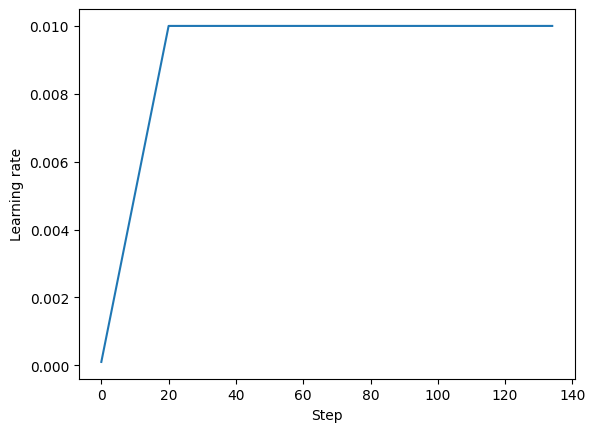

In [6]:
import matplotlib.pyplot as plt
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs);
plt.show()

In [7]:
import math

min_lr = 0.1 * initial_lr
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1
track_lrs = []

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment # set new lr if in warmup phase
            # print(f"Global Step: {global_step}, Learning Rate: {lr:.6f}")
        
        # instead of setting it to the peak lr as we saw previously, we use cosine decay after the warmup phase
        else: 
            progress = ((global_step - warmup_steps) / (total_training_steps - warmup_steps)) # (t / T)
            lr = min_lr + 0.5 * (peak_lr - min_lr) * (1 + math.cos(math.pi * progress)) # η_t = η_min + 1/2 * (η_max - η_min) * (1 + cos((t / T) * π))
        
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        
        track_lrs.append(optimizer.param_groups[0]["lr"])

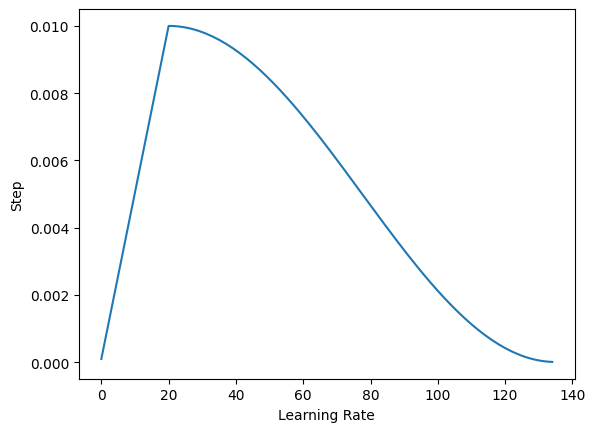

In [8]:
plt.xlabel("Learning Rate")
plt.ylabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs);
plt.show()

In [9]:
from calc_loss_loader import calc_loss_batch

torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M).to(device)

loss = calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()

In [10]:
def find_highest_gradient(model):
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            max_grad_param = grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
                max_grad = max_grad_param
    return max_grad
print(find_highest_gradient(model))

tensor(0.0344, device='cuda:0')


In [11]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0155, device='cuda:0')


In [21]:
from evaluate_model import evaluate_model
from generate_and_print_sample import generate_and_print_sample
import tiktoken

def train_model(model, train_loader, val_loader, optimizer, device, n_epochs, eval_freq, eval_iter, start_context, warmup_steps=10, initial_lr=3e-05, min_lr=1e-6, peak_lr=5e-4):
    
    tokenizer = tiktoken.get_encoding("gpt2")
    
    train_losses, val_losses, num_tokens_seen, track_lrs = [], [], [], []
    
    peak_lr = peak_lr
    total_training_steps = len(train_loader) * n_epochs
    lr_increment_per_step = (peak_lr - initial_lr) / warmup_steps
    global_step = -1
    tokens_seen = 0
    
    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1
            
            if global_step < warmup_steps:
                lr = initial_lr + (global_step * lr_increment_per_step) 
            
            else:
                progress = ((global_step - warmup_steps) / (total_training_steps - warmup_steps))
                lr = min_lr + 0.5 * (peak_lr - min_lr) * (1 + math.cos(math.pi * progress))
            
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
                
            track_lrs.append(optimizer.param_groups[0]["lr"])
            
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            
            if global_step > warmup_steps:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            tokens_seen += input_batch.numel()
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                num_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
        generate_and_print_sample(model, tokenizer, device, start_context)
        
    return train_losses, val_losses, num_tokens_seen, track_lrs

In [23]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)
peak_lr = 5e-4
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)

n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    warmup_steps=10, initial_lr=1e-5, min_lr=1e-5, peak_lr=peak_lr
)

Ep 1 (Iter 000000): Train loss 10.971, Val loss 10.938
Ep 1 (Iter 000005): Train loss 9.193, Val loss 9.312
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Iter 000010): Train loss 7.363, Val loss 7.775
Ep 2 (Iter 000015): Train loss 6.302, Val loss 6.813
Every effort moves you                                                  
Ep 3 (Iter 000020): Train loss 6.208, Val loss 6.628
Ep 3 (Iter 000025): Train loss 5.603, Val loss 6.597
Every effort moves you, the, the the the, the, the, the the, the, the, the, the, the, the, the, the the, the, the, the, the, the, the, the, the, the, the
Ep 4 (Iter 000030): Train loss 5.562, Val loss 6.613
Ep 4 (Iter 000035): Train loss 5.596, Val loss 6.527
Every effort moves you. "I"I. "I the"I.        "I"I had". "I the ." I had".           
Ep 5 (Iter 000040): Train loss 4.590, Val loss 6.434
Every effort moves you in the, and I had been--I had the picture I had been I had been, I had been the, I had been, I had been--I had 

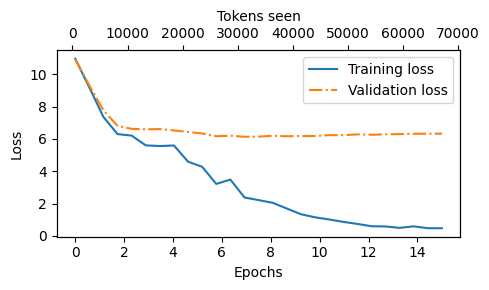

In [25]:
import matplotlib.pyplot as plt
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny() 
    ax2.plot(tokens_seen, train_losses, alpha=0) 
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

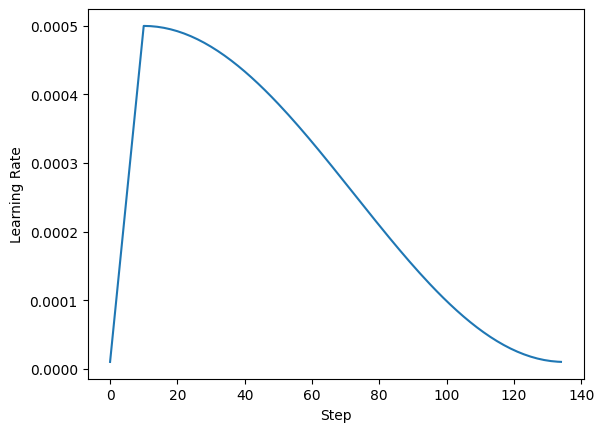

In [26]:
plt.xlabel("Step")
plt.ylabel("Learning Rate")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), lrs);
plt.show()